# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load Dataset

In [2]:
df = pd.read_csv(r"D:\ClimateGuardAI\datasets\processed\D6_kmeans_ready.csv")

print(df.head())

   latitude  longitude  temperature_celsius  wind_kph  wind_degree  \
0     24.57      77.72                 27.5      20.5          281   
1     23.33      77.80                 27.5      15.5          287   
2     22.07      78.93                 26.3      18.4          317   
3     21.86      77.93                 25.6      16.9          297   
4     22.75      77.72                 27.2      16.2          274   

   pressure_mb  precip_mm  humidity  cloud  feels_like_celsius  ...  \
0         1008        0.0        67     26                29.7  ...   
1         1008        0.0        70     19                30.0  ...   
2         1009        0.0        70     51                28.2  ...   
3         1009        0.0        76     65                27.6  ...   
4         1009        0.0        74     82                29.9  ...   

   moon_phase_Waning Gibbous  moon_phase_Waxing Crescent  \
0                        0.0                         0.0   
1                        0.0    

# Feature Selection

In [3]:
features = [
    'temperature_celsius',
    'humidity',
    'precip_mm',
    'pressure_mb',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'visibility_km',
    'uv_index'
]

X = df[features]
X = X.fillna(X.mean())

# Data Scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Hyperparameter Tuning (K-Means Optimization)

# Elbow Method + Silhouette Score

In [5]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    # FAST SILHOUETTE (FIX)
    silhouette_scores.append(
        silhouette_score(
            X_scaled,
            clusters,
            sample_size=2000,   # KEY FIX
            random_state=42
        )
    )

print("Done!")

Done!


# Elbow Curve

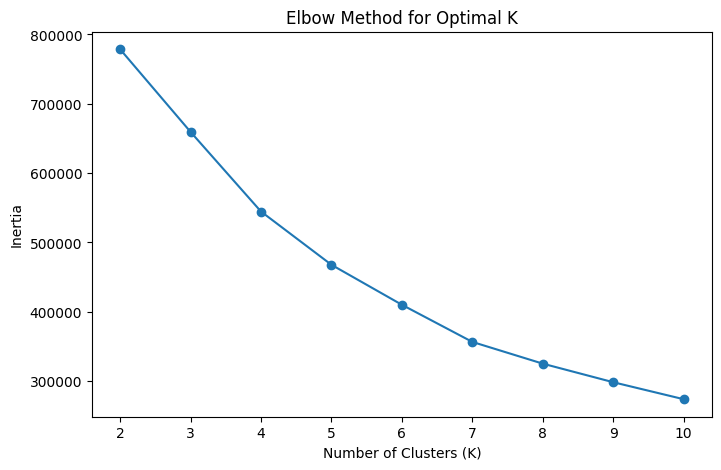

In [6]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Silhouette Score Plot

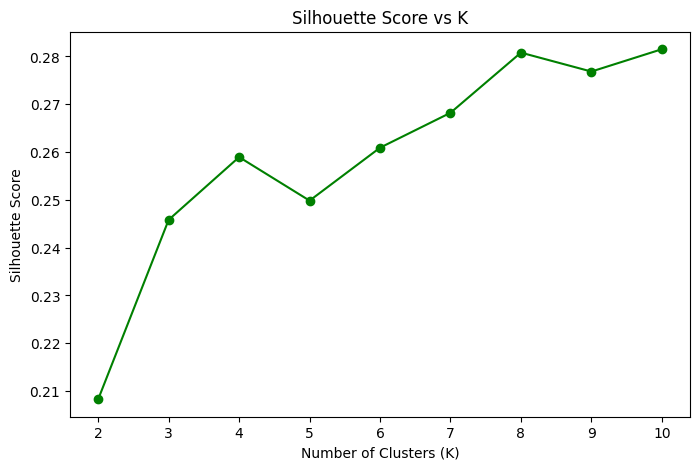

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o',
    color='green'   # change this color
)

plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

# Select Best K

In [8]:
best_k = K_range[np.argmax(silhouette_scores)]
print("Best K based on Silhouette Score:", best_k)

Best K based on Silhouette Score: 10


# Final K-Means Model (After Tuning)

In [9]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_scaled)
df = df.copy()
df['Cluster'] = clusters

print(df['Cluster'].value_counts())
df = df.copy()
df['Cluster'] = clusters


Cluster
3    25613
2    24951
1    18468
0    16191
4    15150
5    11764
9     4777
6     1657
7      798
8       29
Name: count, dtype: int64


# Cluster Centers

In [10]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

print(cluster_centers)

   temperature_celsius   humidity  precip_mm  pressure_mb  air_quality_PM2.5  \
0            25.232735  81.378687   0.207084  1005.480871          39.818592   
1            22.126237  82.300433   0.058919  1012.759123          70.080623   
2            23.966293  32.358677   0.001519  1012.267214          59.957138   
3            20.142821  71.830635   0.027059  1013.594297          66.976058   
4            16.920802  49.154029   0.003363  1015.257113         212.095421   
5             8.472245  52.915130   0.020845  1019.299890          51.692736   
6            28.299457  69.961376   0.178576  1006.378998          47.139409   
7            22.826692  93.280702   4.501754  1006.610276          24.952256   
8            23.079310  95.931034  23.430690  1004.931034          13.817241   
9            14.902455  64.234578   0.006106  1016.540076         406.787998   

   air_quality_PM10  visibility_km  uv_index  
0         48.919036       9.767605  1.002221  
1         85.955425      

# PCA Visualization



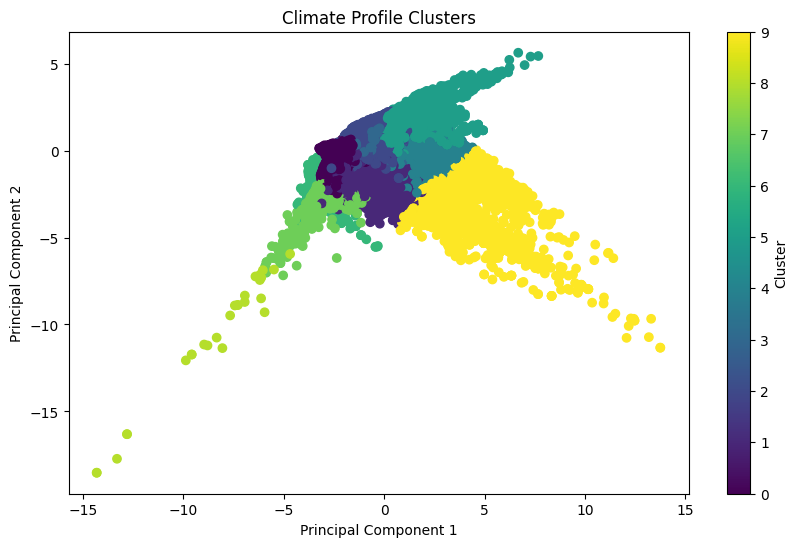

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Climate Profile Clusters')
plt.colorbar(label='Cluster')
plt.show()

# Cluster Summary

In [12]:
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

         temperature_celsius   humidity  precip_mm  pressure_mb  \
Cluster                                                           
0                  25.236106  81.373788   0.206832  1005.475449   
1                  22.126359  82.302036   0.058926  1012.759747   
2                  23.966322  32.364555   0.001518  1012.266763   
3                  20.145044  71.864288   0.027365  1013.591848   
4                  16.928693  49.163894   0.003357  1015.254323   
5                   8.469288  52.920520   0.020858  1019.300918   
6                  28.299457  69.961376   0.178576  1006.378998   
7                  22.826692  93.280702   4.501754  1006.610276   
8                  23.079310  95.931034  23.430690  1004.931034   
9                  14.896002  64.192589   0.006092  1016.541344   

         air_quality_PM2.5  air_quality_PM10  visibility_km  uv_index  
Cluster                                                                
0                39.834223         48.936119       


# Assign Climate Labels

In [13]:
climate_names = {
    0: 'Flood-Prone Climate',
    1: 'Heatwave-Prone Climate',
    2: 'Pollution-Prone Climate',
    3: 'Moderate Climate'
}
df = df.copy()
df['Climate_Profile'] = df['Cluster'].map(climate_names)

print(df[['Cluster', 'Climate_Profile']].head())

   Cluster Climate_Profile
0        6             NaN
1        6             NaN
2        6             NaN
3        6             NaN
4        6             NaN


# Save Engineered Dataset

In [14]:
output_dir = r"D:\ClimateGuardAI\datasets\engineered"
output_path = f"{output_dir}/climate_profile_engineered.csv"

df.to_csv(output_path, index=False)

print(f"Climate profiles saved successfully at:\n{output_path}")

Climate profiles saved successfully at:
D:\ClimateGuardAI\datasets\engineered/climate_profile_engineered.csv


# Save Model & Scaler

In [15]:
import pickle
import os

save_path = r"D:\ClimateGuardAI\backend\ml\artifacts"

os.makedirs(save_path, exist_ok=True)

with open(os.path.join(save_path, 'climate_kmeans.pkl'), 'wb') as file:
    pickle.dump(kmeans, file)

with open(os.path.join(save_path, 'climate_scaler.pkl'), 'wb') as file:
    pickle.dump(scaler, file)

print("Models saved successfully.")
print("Files saved in:", save_path)

Models saved successfully.
Files saved in: D:\ClimateGuardAI\backend\ml\artifacts


# FINAL SUMMARY

In [16]:
# ✔ Yes — clustering also has hyperparameter tuning
# ✔ Instead of GridSearchCV → you use:

# * Elbow Method
# * Silhouette Score

# ✔ Best K is automatically selected
# ✔ This makes your project **industry-level ML clustering pipeline